Shape of data: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  

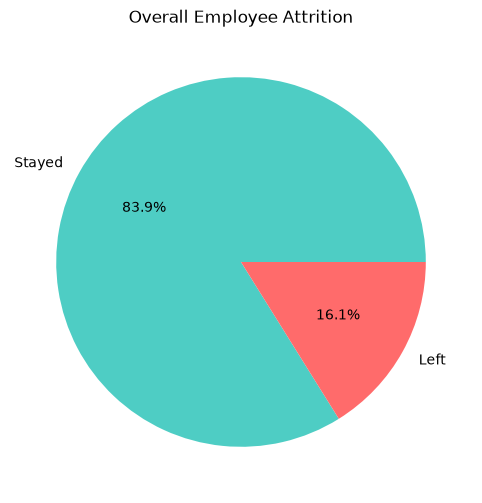

Chart 1 saved
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition_Num, dtype: float64


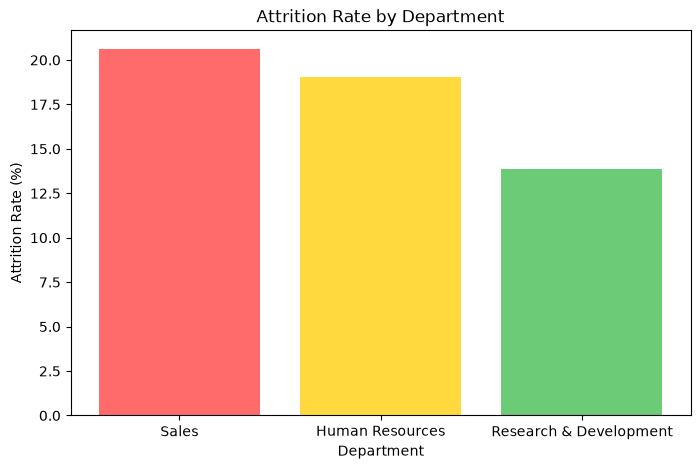

Chart 2 saved
Age_Group
18-30    25.906736
31-40    13.731826
41-50    10.559006
51+      12.587413
Name: Attrition_Num, dtype: float64


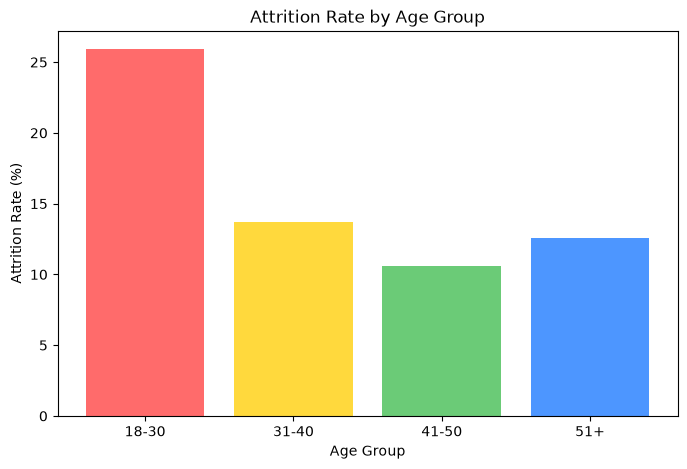

Chart 3 saved


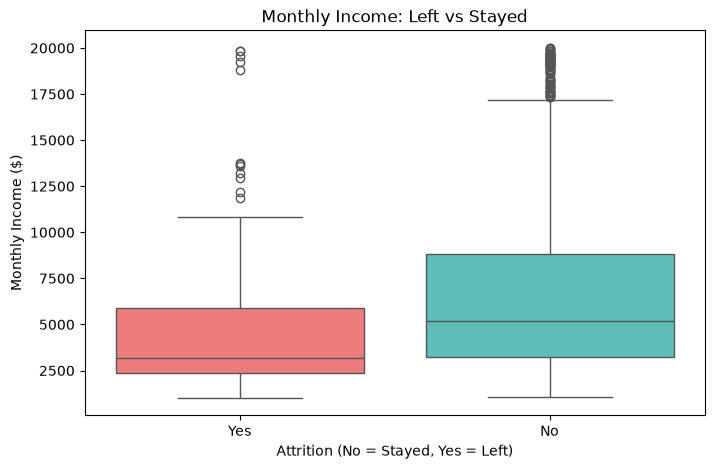

Chart 4 saved
OverTime
No     10.436433
Yes    30.528846
Name: Attrition_Num, dtype: float64


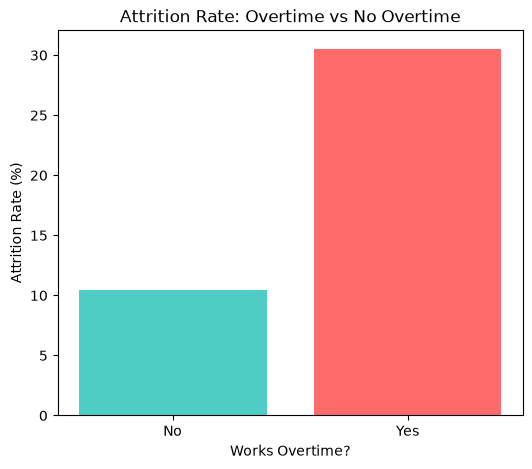

Chart 5 saved
                 Attrition_Num       Age  MonthlyIncome  YearsAtCompany  \
Attrition_Num         1.000000 -0.159205      -0.159840       -0.134392   
Age                  -0.159205  1.000000       0.497855        0.311309   
MonthlyIncome        -0.159840  0.497855       1.000000        0.514285   
YearsAtCompany       -0.134392  0.311309       0.514285        1.000000   
JobSatisfaction      -0.103481 -0.004892      -0.007157       -0.003803   
WorkLifeBalance      -0.063939 -0.021490       0.030683        0.012089   
OverTime_Num          0.246118  0.028062       0.006089       -0.011687   

                 JobSatisfaction  WorkLifeBalance  OverTime_Num  
Attrition_Num          -0.103481        -0.063939      0.246118  
Age                    -0.004892        -0.021490      0.028062  
MonthlyIncome          -0.007157         0.030683      0.006089  
YearsAtCompany         -0.003803         0.012089     -0.011687  
JobSatisfaction         1.000000        -0.019459      

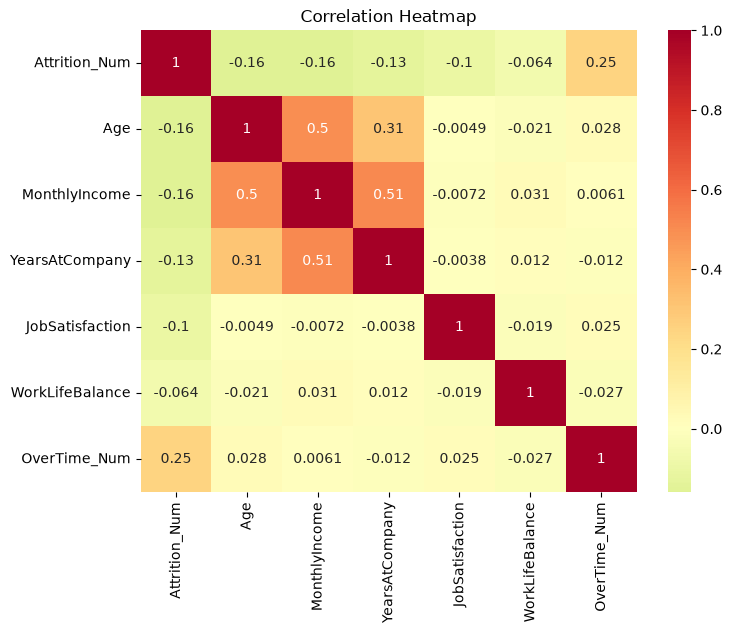

Chart 6 saved


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/sarav/OneDrive/Desktop/hr_attrition/hr_attrition_.csv")

print("Shape of data:", df.shape)
print(df.head())
print(df.isnull().sum())

# Create numeric helper columns early so every chart below can use them
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime_Num'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Create Age_Group column - needed for Chart 3
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 30, 40, 50, 100],
    labels=['18-30', '31-40', '41-50', '51+']
)

# CHART 1 - Overall Attrition (Pie Chart)
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
plt.figure(figsize=(6, 6))
plt.pie(
    attrition_counts,
    labels=['Stayed', 'Left'],
    colors=['#4ECDC4', '#FF6B6B'],
    autopct='%1.1f%%'
)
plt.title('Overall Employee Attrition')
plt.savefig('chart1_attrition_donut.png')
plt.show()
print("Chart 1 saved")


# CHART 2 - Attrition by Department (Bar Chart)
dept_rate = df.groupby('Department')['Attrition_Num'].mean() * 100
dept_rate = dept_rate.sort_values(ascending=False)
print(dept_rate)

plt.figure(figsize=(8, 5))
plt.bar(dept_rate.index, dept_rate.values, color=['#FF6B6B', '#FFD93D', '#6BCB77'])
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.savefig('chart2_attrition_by_department.png')
plt.show()
print("Chart 2 saved")


# CHART 3 - Attrition by Age Group (Bar Chart)
age_rate = df.groupby('Age_Group', observed=True)['Attrition_Num'].mean() * 100
age_rate = age_rate.reindex(['18-30', '31-40', '41-50', '51+'])
print(age_rate)

plt.figure(figsize=(8, 5))
plt.bar(age_rate.index, age_rate.values, color=['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF'])
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.savefig('chart3_attrition_by_age.png')
plt.show()
print("Chart 3 saved")


# CHART 4 - Monthly Income vs Attrition (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    hue='Attrition',
    palette={'No': '#4ECDC4', 'Yes': '#FF6B6B'},
    legend=False
)
plt.title('Monthly Income: Left vs Stayed')
plt.xlabel('Attrition (No = Stayed, Yes = Left)')
plt.ylabel('Monthly Income ($)')
plt.savefig('chart4_income_vs_attrition.png')
plt.show()
print("Chart 4 saved")


# CHART 5 - Overtime vs Attrition (Bar Chart)
overtime_rate = df.groupby('OverTime')['Attrition_Num'].mean() * 100
print(overtime_rate)

plt.figure(figsize=(6, 5))
plt.bar(overtime_rate.index, overtime_rate.values, color=['#4ECDC4', '#FF6B6B'])
plt.title('Attrition Rate: Overtime vs No Overtime')
plt.xlabel('Works Overtime?')
plt.ylabel('Attrition Rate (%)')
plt.savefig('chart5_overtime_vs_attrition.png')
plt.show()
print("Chart 5 saved")


# CHART 6 - Correlation Heatmap
# out of all the numeric columns, which ones move together with attrition?
columns_to_check = [
    'Attrition_Num', 'Age', 'MonthlyIncome', 'YearsAtCompany',
    'JobSatisfaction', 'WorkLifeBalance', 'OverTime_Num'
]

correlation_table = df[columns_to_check].corr()
print(correlation_table)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_table, annot=True, cmap='RdYlGn_r', center=0)
plt.title('Correlation Heatmap')
plt.savefig('chart6_correlation_heatmap.png')
plt.show()
print("Chart 6 saved")